In [1]:
import argparse
import os
import sys
import time

import basix
import dolfinx
import matplotlib.pyplot as plt
import numpy as np
import scifem
import ufl

from dolfinx import fem, mesh

from dolfinx.cpp.mesh import cell_num_entities

from dolfinx.fem.petsc import assemble_matrix_block, assemble_vector_block, NonlinearProblem
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.io import gmshio, VTXWriter
from dolfinx.nls import petsc as petsc_nls
from mpi4py import MPI
from petsc4py import PETSc
from ufl import avg, div, dot, grad, inner, jump

import commons, mesh_utils, solver_params, solvers, utils


faraday_const = 96485
R = 8.3145
T = 298
a = 100
i0 = 10
alpha_a = 0.5
alpha_c = 0.5
kappa = 4
# w = 99 #a * i0 * (alpha_a + alpha_c)/kappa * faraday_const/(R*T)
ip = 1e1
w = np.sqrt(a * i0 * (alpha_a + alpha_c) * faraday_const / (kappa * R * T))

In [2]:
comm = MPI.COMM_WORLD
domain = mesh.create_interval(comm, 1000, [0, 0.1])
tdim = domain.topology.dim
fdim = tdim - 1
ft_imap = domain.topology.index_map(fdim)
num_facets = ft_imap.size_local + ft_imap.num_ghosts
indices = np.arange(0, num_facets)
values = np.zeros(indices.shape, dtype=np.intc)
left_marker = 1
right_marker = 2

values[0] = left_marker
values[-1] = right_marker
ft = mesh.meshtags(domain, fdim, indices, values)

In [3]:
def left_boundary(x):
    return np.isclose(x[0], 0)

def right_boundary(x):
    return np.isclose(x[0], 1)

In [4]:
V = fem.functionspace(domain, ("CG", 1))

In [5]:
u, v = fem.Function(V), ufl.TestFunction(V)

In [6]:
def i_bv(phi, i0=i0):
    return i0 * ufl.sinh(0.5 * faraday_const/(R * T) * phi)

def i_linear(phi, i0=10):
    return w ** 2 * phi #i0 * faraday_const/(R * T) * phi

In [7]:
dx = ufl.Measure('dx', domain=domain)
ds = ufl.Measure('ds', domain=domain, subdomain_data=ft)

In [8]:
u_right = fem.Function(V)
u_right.x.array[:] = 0
domain.topology.create_connectivity(fdim, tdim)
right_bc = fem.dirichletbc(
    u_right, fem.locate_dofs_topological(V, fdim, ft.find(right_marker))
)

In [9]:
# F0 = inner(kappa * grad(u), grad(v)) * dx  - a * i_linear(u) * v * dx + ip * v * ds(left_marker)
F0 = inner(kappa * grad(u), grad(v)) * dx  - i_linear(u) * v * dx - ip * v * ds(left_marker)
# limit function
# x = ufl.SpatialCoordinate(domain)
# f_lim = fem.Expression(ufl.cosh(w*x[0]) - ufl.sinh(w*x[0]), V.element.interpolation_points)
# gamma = 5
# F0 += gamma * (u - f_lim) * v * ds(right_marker)
# F0 += - kappa * inner(grad(u), n) * v * ds(right_marker)
# F0 += - kappa * inner(grad(v), n) * (u  - f_lim) * ds(right_marker)

In [10]:
F = [fem.form(F0)]
j00 = fem.form(ufl.derivative(F0, u))
J = [[j00]]

In [11]:
opts = {
            'ksp_type': 'preonly',
            'pc_type': 'lu',
            # 'pc_factor_levels': 0,
            # 'pc_factor_fill': 2.0,
            }

solver = scifem.NewtonSolver(F, J, [u], bcs=[], petsc_options=opts)

t0 = time.time()
solver.solve()
t1 = time.time()
PETSc.Sys.Print(f"Solve time: {t1 - t0:.3f}s")

Solve time: 0.010s


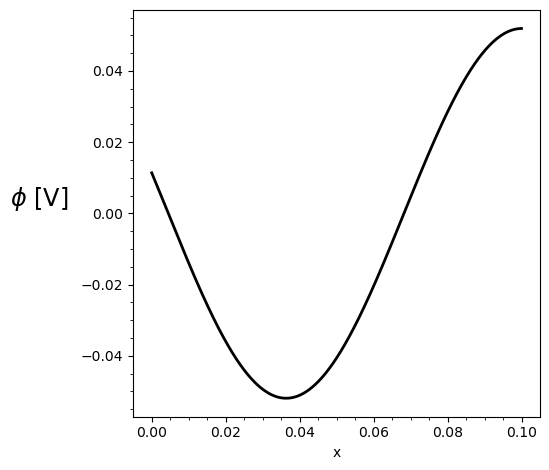

In [12]:
bb_trees = bb_tree(domain, domain.topology.dim)
n_points = 10000
tol = 1e-8  # Avoid hitting the outside of the domain
x = np.linspace(tol, 1.0 - tol, n_points)
points = np.zeros((3, n_points))
points[0] = x
u_values = []
cells = []
points_on_proc = []
cell_candidates = compute_collisions_points(bb_trees, points.T)
colliding_cells = compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
points_on_proc = np.array(points_on_proc, dtype=np.float64)
u_values = u.eval(points_on_proc, cells)
fig, ax = plt.subplots()
ax.plot(points_on_proc[:, 0], u_values, "k", linewidth=2)
# ax.set_xlim([0, 1])
ax.set_ylabel(r'$\phi$ [V]', rotation=0, labelpad=30, fontsize='xx-large')
ax.set_xlabel(r'x')
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.show()

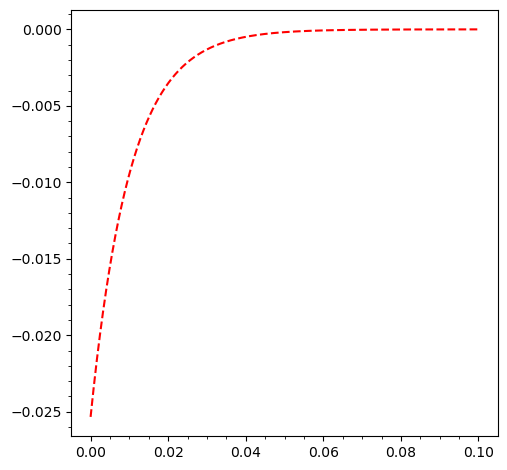

In [13]:
fig, ax = plt.subplots()
def y_val(x):
    return (-ip / kappa / w) * (np.cosh(w * x) - np.sinh(w * x))
ax.plot(points_on_proc[:, 0], [y_val(p) for p in points_on_proc[:, 0]], 'r--')
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.show()

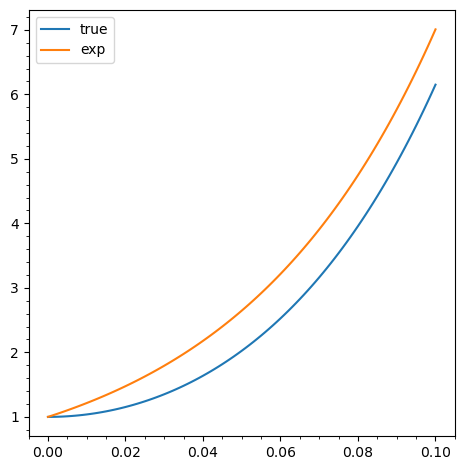

In [24]:
x = np.linspace(0, 0.1, 101)
y_true = np.exp(0.5 * faraday_const * x/(R * T)) + np.exp(-0.5 * faraday_const * x/(R * T)) - 1
y_exp = np.exp(0.5 * faraday_const * x/(R * T))

fig, ax = plt.subplots()
ax.plot(x, y_true, label='true')
ax.plot(x, y_exp, label='exp')
ax.set_box_aspect(1);
ax.minorticks_on();
ax.legend();
plt.tight_layout()
plt.show()

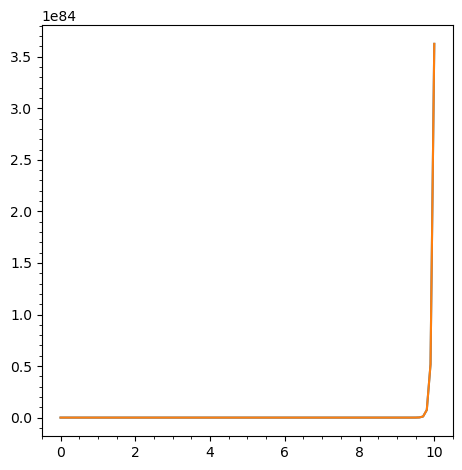